<a href="https://colab.research.google.com/github/ngoan22mse23088/ArtificialIntelligence/blob/master/Lung_EffNet_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adityamahimkar_iqothnccd_lung_cancer_dataset_path = kagglehub.dataset_download('adityamahimkar/iqothnccd-lung-cancer-dataset')

print('Data source import complete.')


In [ ]:
import kagglehub
from pathlib import Path
from collections import defaultdict
import json
from PIL import Image
import numpy as np

# Download dataset
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
print("Path to dataset files:", path)

# ── Tự động tìm ảnh trong path vừa download ──
root = Path(path)
ALLOWED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}
EXPECTED_MODES = {"RGB", "L"}

image_files = [f for f in root.rglob("*")
               if f.is_file() and f.suffix.lower() in ALLOWED_EXTS]

print(f"\n📁 Dataset: {root}")
print(f"🖼️  Tổng số ảnh: {len(image_files)}")

if len(image_files) == 0:
    all_files = list(root.rglob("*.*"))
    exts = set(f.suffix.lower() for f in all_files if f.is_file())
    print(f"⚠️  Không tìm thấy ảnh! Extensions thực tế: {exts}")
    for f in all_files[:10]:
        print(f"  {f.relative_to(root)}")
else:
    errors        = []
    size_counter  = defaultdict(int)
    mode_counter  = defaultdict(int)
    class_counter = defaultdict(int)
    ext_counter   = defaultdict(int)

    for i, p in enumerate(image_files, 1):
        if i % 300 == 0:
            print(f"  ... {i}/{len(image_files)}")
        issues = []
        class_counter[p.parent.name] += 1
        ext_counter[p.suffix.lower()] += 1

        if p.stat().st_size < 1024:
            issues.append(f"File quá nhỏ ({p.stat().st_size} bytes)")

        try:
            with Image.open(p) as img:
                w, h, mode = img.width, img.height, img.mode
                size_counter[f"{w}x{h}"] += 1
                mode_counter[mode] += 1
                if mode not in EXPECTED_MODES:
                    issues.append(f"Mode không hợp lệ: {mode}")
                if np.array(img).std() < 1.0:
                    issues.append("Ảnh một màu (std≈0)")
        except Exception as e:
            issues.append(f"Không đọc được: {e}")

        if issues:
            errors.append({"file": str(p.relative_to(root)), "issues": issues})

    total = len(image_files)
    n_ok  = total - len(errors)

    print(f"\n{'═'*55}")
    print(f"  Tổng ảnh    : {total}")
    print(f"  ✅ Đạt chuẩn : {n_ok}  ({n_ok/total*100:.1f}%)")
    print(f"  ❌ Có vấn đề : {len(errors)}  ({len(errors)/total*100:.1f}%)")

    print(f"\n  📂 PHÂN BỐ THEO CLASS:")
    max_c = max(class_counter.values())
    for cls, cnt in sorted(class_counter.items()):
        bar = "█" * int(cnt / max_c * 25)
        print(f"    {cls:<30} {cnt:>4}  {bar}")

    print(f"\n  📐 KÍCH THƯỚC PHỔ BIẾN:")
    for size, cnt in sorted(size_counter.items(), key=lambda x: -x[1])[:8]:
        print(f"    {size:<15} {cnt:>4} ảnh")

    print(f"\n  🎨 MODE MÀU:")
    for mode, cnt in sorted(mode_counter.items(), key=lambda x: -x[1]):
        mark = "✅" if mode in EXPECTED_MODES else "❌"
        print(f"    {mode:<10} {cnt:>4} ảnh  {mark}")

    print(f"\n  📄 ĐỊNH DẠNG FILE:")
    for ext, cnt in sorted(ext_counter.items(), key=lambda x: -x[1]):
        print(f"    {ext:<10} {cnt:>4} ảnh")

    if errors:
        print(f"\n  ❌ MẪU LỖI (tối đa 20):")
        for e in errors[:20]:
            print(f"  [{e['file']}]")
            for iss in e["issues"]:
                print(f"    → {iss}")
        out = Path("/kaggle/working/error_images.json")
        out.write_text(json.dumps(errors, ensure_ascii=False, indent=2))
        print(f"\n  📋 Đã lưu lỗi → {out}")
    else:
        print(f"\n  🎉 Tất cả ảnh đều đạt chuẩn!")
    print(f"{'═'*55}")

Path to dataset files: /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset

📁 Dataset: /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
🖼️  Tổng số ảnh: 1294
  ... 300/1294
  ... 600/1294
  ... 900/1294
  ... 1200/1294

═══════════════════════════════════════════════════════
  Tổng ảnh    : 1294
  ✅ Đạt chuẩn : 1294  (100.0%)
  ❌ Có vấn đề : 0  (0.0%)

  📂 PHÂN BỐ THEO CLASS:
    Bengin cases                    120  █████
    Malignant cases                 561  █████████████████████████
    Normal cases                    416  ██████████████████
    Test cases                      197  ████████

  📐 KÍCH THƯỚC PHỔ BIẾN:
    512x512         1230 ảnh
    623x512           31 ảnh
    801x512           28 ảnh
    768x768            3 ảnh
    506x331            1 ảnh
    511x404            1 ảnh

  🎨 MODE MÀU:
    RGB        1294 ảnh  ✅

  📄 ĐỊNH DẠNG FILE:
    .jpg       1097 ảnh
    .png        197 ảnh

  🎉 Tất cả ảnh đều đạt chuẩn!
════════════════════

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Device: cuda
Data root: /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
Classes (2): ['Test cases', 'The IQ-OTHNCCD lung cancer dataset']
Total samples: 1294
Train: 905 | Val: 194 | Test: 195

  Training: Inception-ResNet-V2


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]


Epoch 1/15


...

  Train Loss: 0.0002  Acc: 1.0000
  Val   Loss: 0.0000  Acc: 1.0000

Epoch 15/15


Eval: 100%|██████████| 13/13 [00:02<00:00,  5.26it/s] 


  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0047  Acc: 1.0000


Eval: 100%|██████████| 13/13 [00:02<00:00,  5.13it/s]



Test Loss: 0.0000  Test Acc: 1.0000
  Macro-F1      : 100.0%
  Micro-F1      : 100.0%
  Weighted-F1   : 100.0%
  Macro-Recall  : 100.0%
  Macro-Precision: 100.0%
  Cohen's Kappa : 1.0
  AUC-ROC       : 100.0%

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



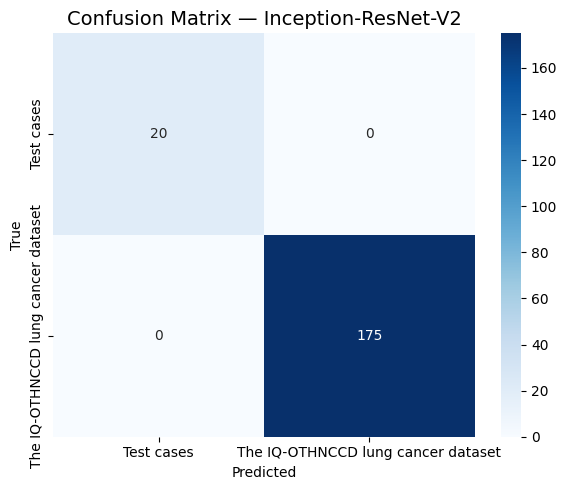

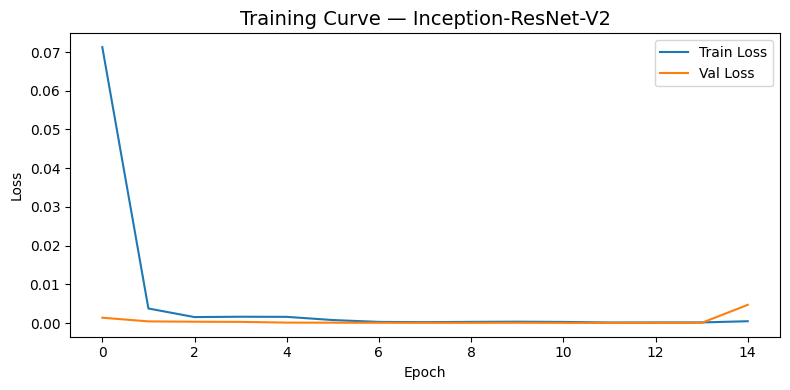


  Training: EfficientNet-B1
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 145MB/s] 



Epoch 1/15


Eval: 100%|██████████| 13/13 [00:01<00:00,  9.49it/s] 


  Train Loss: 0.2635  Acc: 0.9470
  Val   Loss: 0.0170  Acc: 1.0000
  ✅ Model saved

Epoch 2/15


...

  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0001  Acc: 1.0000

Epoch 15/15


Eval: 100%|██████████| 13/13 [00:01<00:00,  9.26it/s] 


  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0000  Acc: 1.0000
  ✅ Model saved


Eval: 100%|██████████| 13/13 [00:01<00:00,  9.57it/s]



Test Loss: 0.0001  Test Acc: 1.0000
  Macro-F1      : 100.0%
  Micro-F1      : 100.0%
  Weighted-F1   : 100.0%
  Macro-Recall  : 100.0%
  Macro-Precision: 100.0%
  Cohen's Kappa : 1.0
  AUC-ROC       : 100.0%

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



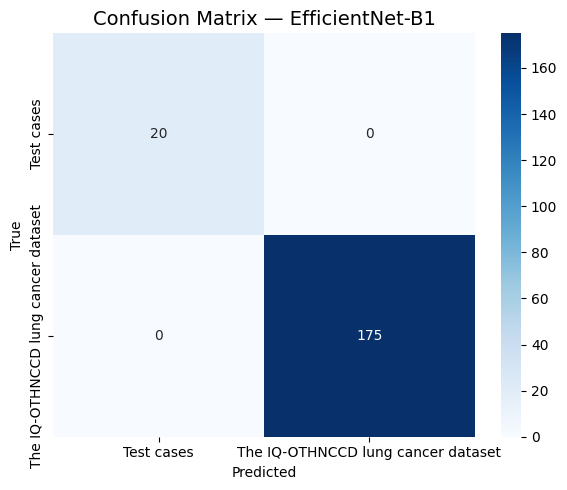

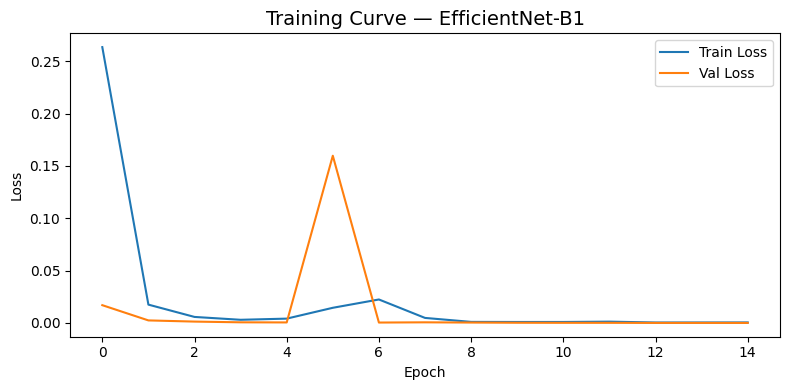


  Training: ResNet-50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 



Epoch 1/15


Eval: 100%|██████████| 13/13 [00:01<00:00,  8.18it/s] 


  Train Loss: 0.1334  Acc: 0.9503
  Val   Loss: 0.0031  Acc: 1.0000
  ✅ Model saved

Epoch 2/15


...

  Train Loss: 0.0001  Acc: 1.0000
  Val   Loss: 0.0000  Acc: 1.0000
  ✅ Model saved

Epoch 15/15


Eval: 100%|██████████| 13/13 [00:01<00:00,  8.02it/s] 


  Train Loss: 0.0000  Acc: 1.0000
  Val   Loss: 0.0000  Acc: 1.0000
  ✅ Model saved


Eval: 100%|██████████| 13/13 [00:01<00:00,  8.14it/s]



Test Loss: 0.0000  Test Acc: 1.0000
  Macro-F1      : 100.0%
  Micro-F1      : 100.0%
  Weighted-F1   : 100.0%
  Macro-Recall  : 100.0%
  Macro-Precision: 100.0%
  Cohen's Kappa : 1.0
  AUC-ROC       : 100.0%

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



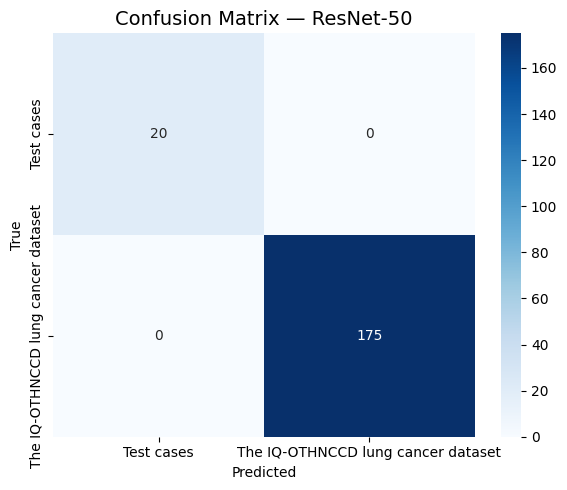

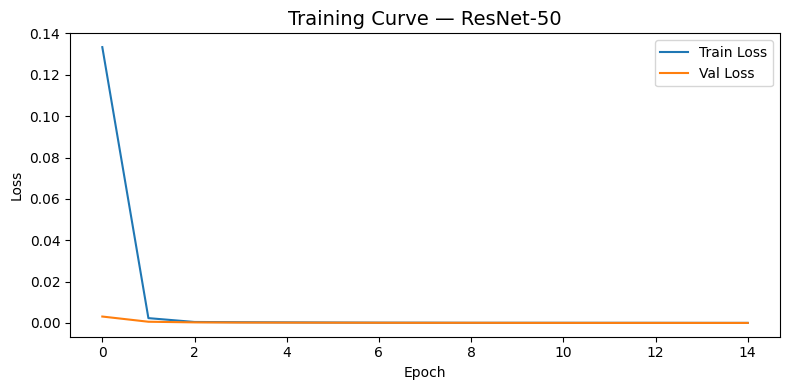


  MODEL COMPARISON DASHBOARD


/tmp/ipykernel_58/1162884901.py:381: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUT_DIR}/comparison_dashboard.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


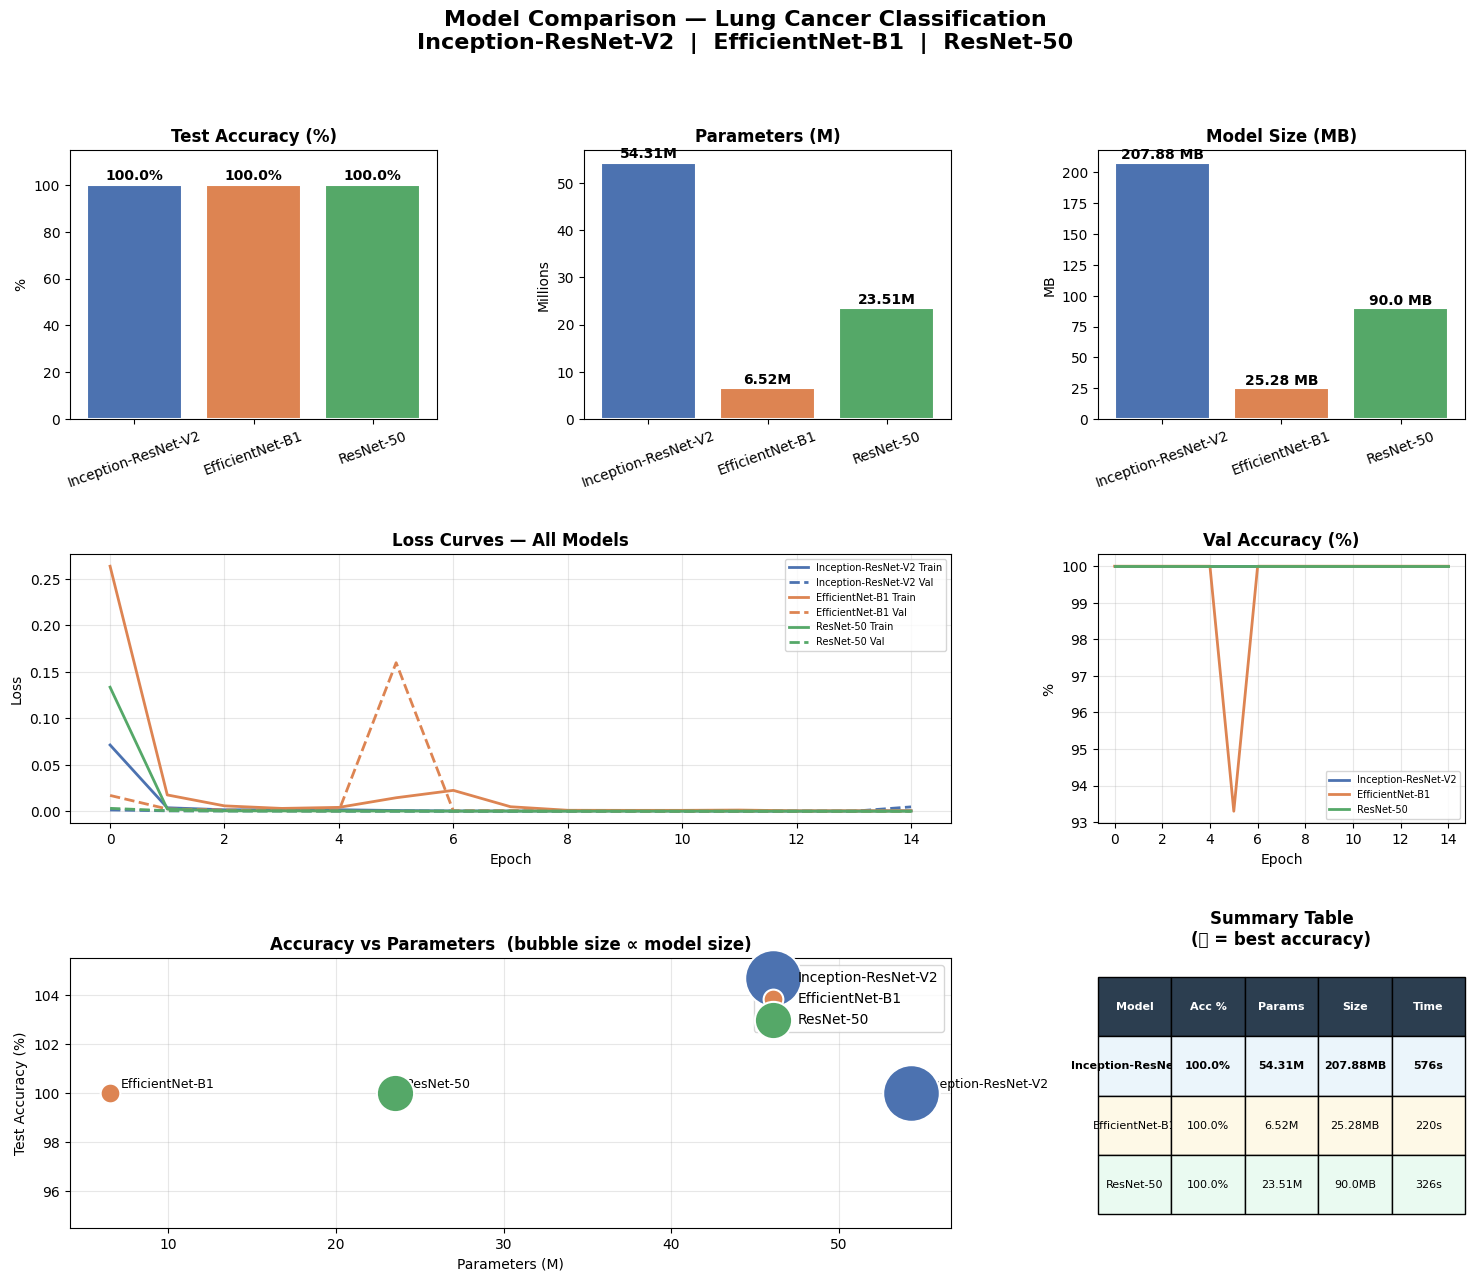


📊 Dashboard saved → /kaggle/working/outputs/comparison_dashboard.png

──────────────────────────────────────────────────────────────
  Model                        Acc    Params     Size     Time
──────────────────────────────────────────────────────────────
  Inception-ResNet-V2       100.0%   54.31M  207.9MB    576s ⭐
  EfficientNet-B1           100.0%    6.52M   25.3MB    220s ⭐
  ResNet-50                 100.0%   23.51M   90.0MB    326s ⭐
──────────────────────────────────────────────────────────────

  SECTION 7: METRICS COMPARISON
  Macro-F1 | Micro-F1 | Weighted-F1 | Recall | Precision
  Cohen's Kappa | AUC-ROC


/tmp/ipykernel_58/1162884901.py:549: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUT_DIR}/metrics_dashboard.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


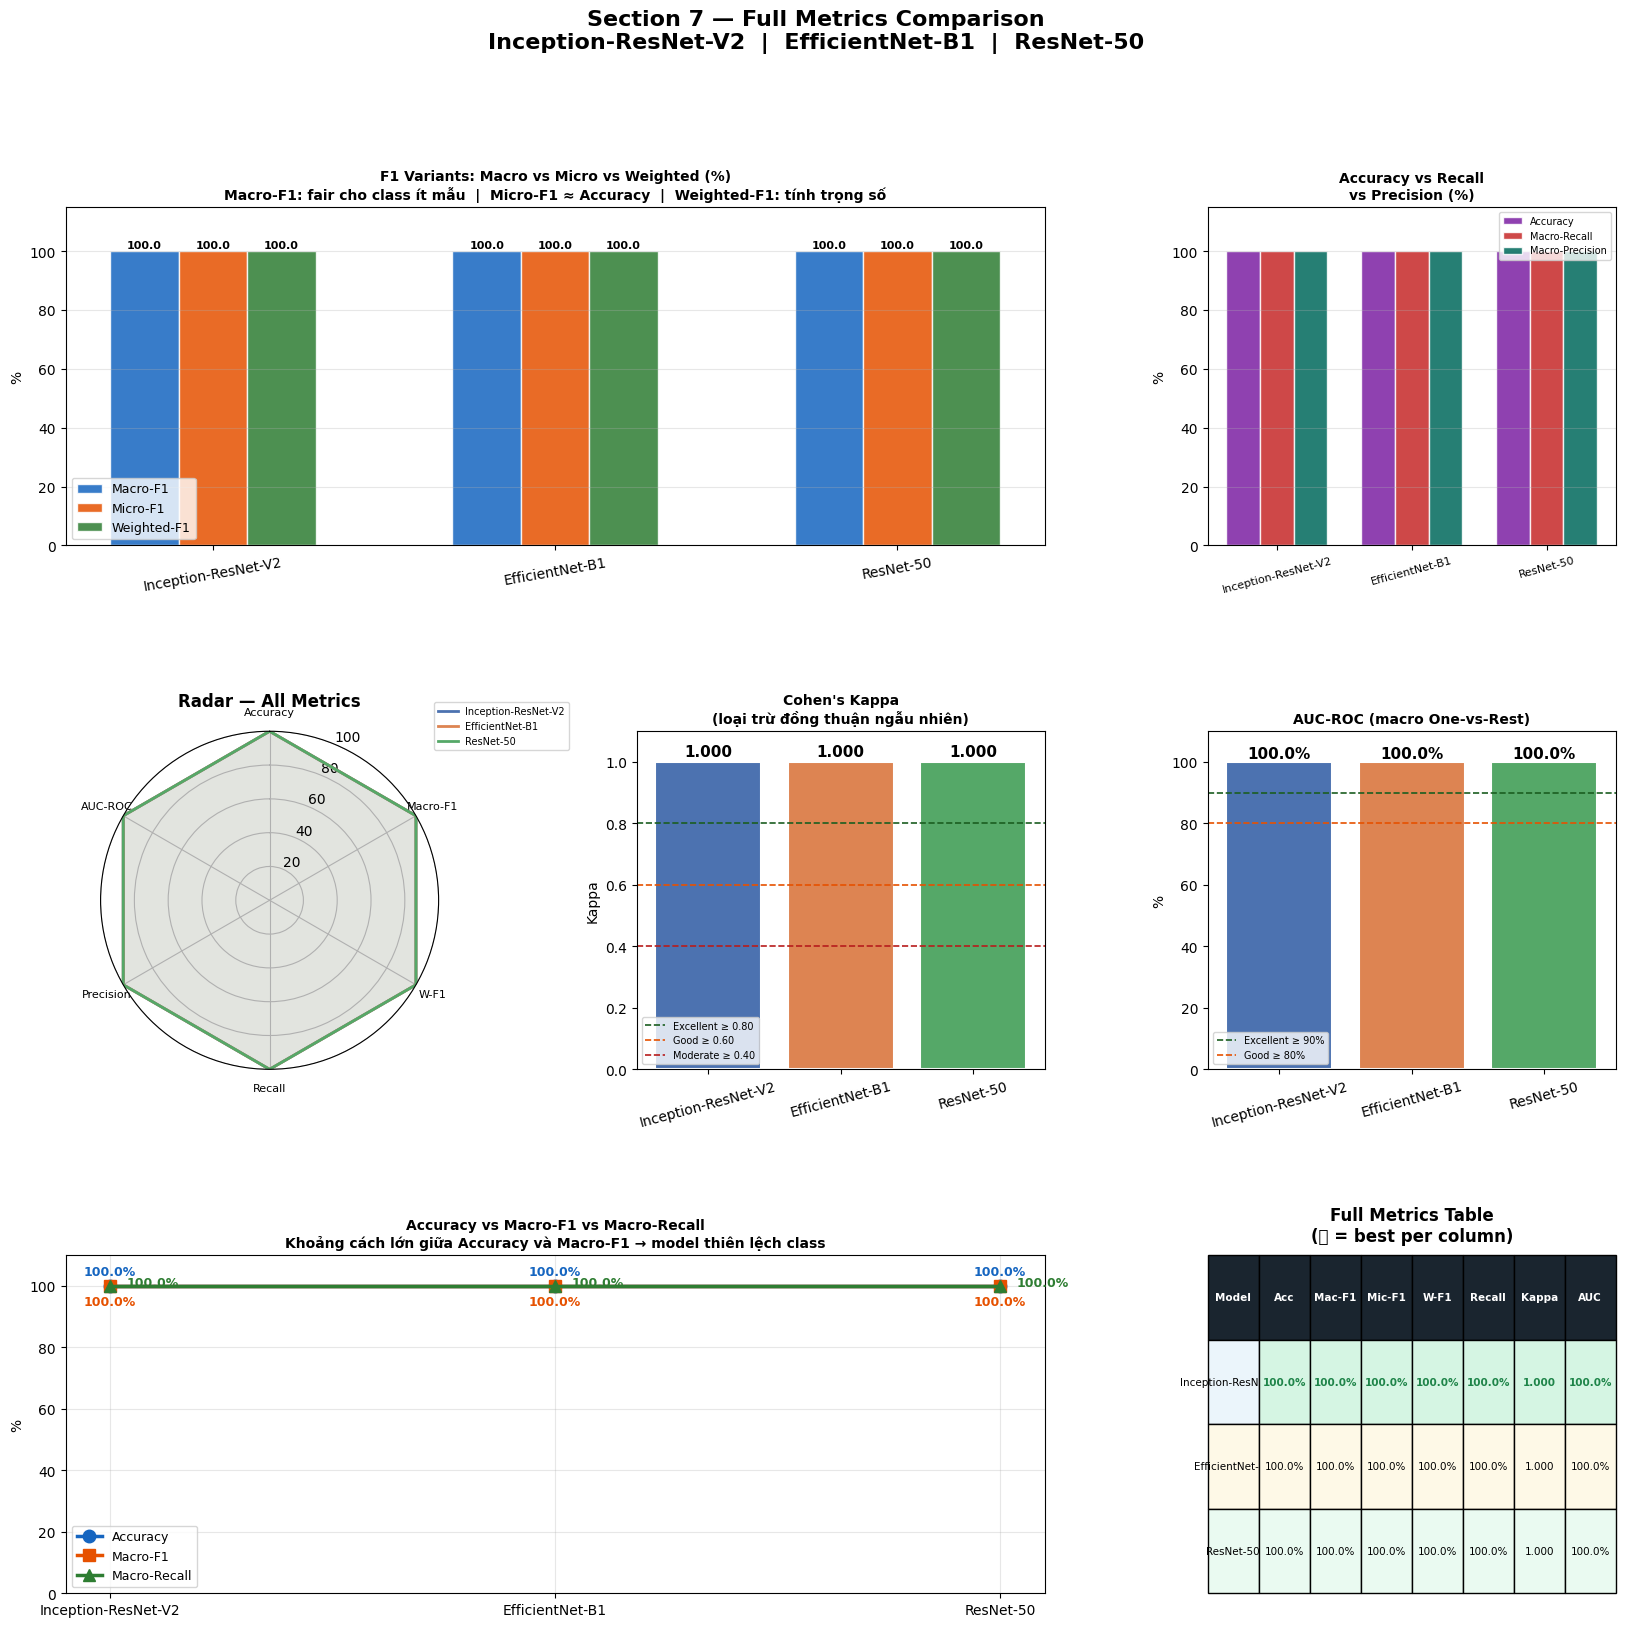


📊 Metrics dashboard saved → /kaggle/working/outputs/metrics_dashboard.png

────────────────────────────────────────────────────────────────────────────────────────
  Model                        Acc   Mac-F1   Mic-F1     W-F1   Recall   Kappa      AUC
────────────────────────────────────────────────────────────────────────────────────────
  Inception-ResNet-V2       100.0%   100.0%   100.0%   100.0%   100.0%   1.000   100.0%
  EfficientNet-B1           100.0%   100.0%   100.0%   100.0%   100.0%   1.000   100.0%
  ResNet-50                 100.0%   100.0%   100.0%   100.0%   100.0%   1.000   100.0%
────────────────────────────────────────────────────────────────────────────────────────
📋 Results saved → /kaggle/working/outputs/results.json


In [ ]:
"""
Lung Cancer Classification - 3 Model Comparison
Models: Inception-ResNet-V2 | EfficientNet-B1 | ResNet-50
Metrics: Accuracy, Macro-F1, Micro-F1, Weighted-F1,
         Macro-Recall, Macro-Precision, Cohen's Kappa, AUC-ROC
Framework: PyTorch + torchvision + timm
"""

# ─── 0. INSTALL & IMPORTS ──────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "timm", "-q"], check=True)

import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import (
    resnet50,        ResNet50_Weights,
    efficientnet_b1, EfficientNet_B1_Weights,
)
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    cohen_kappa_score, roc_auc_score, accuracy_score,
)

# ─── 1. CONFIG ─────────────────────────────────────────────────────────────────
import kagglehub
path     = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
DATA_DIR = path
OUT_DIR  = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE     = 299
BATCH_SIZE   = 16
EPOCHS       = 15
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ─── 2. DATASET ────────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

root = Path(DATA_DIR)
candidates = [root] + [d for d in root.iterdir() if d.is_dir()]
DATA_ROOT = next(
    (d for d in candidates
     if any(True for _ in d.glob("*/*.jpg")) or
        any(True for _ in d.glob("*/*.png"))),
    root
)
print(f"Data root: {DATA_ROOT}")

full_ds     = datasets.ImageFolder(str(DATA_ROOT))
classes     = full_ds.classes
NUM_CLASSES = len(classes)
print(f"Classes ({NUM_CLASSES}): {classes}")
print(f"Total samples: {len(full_ds)}")

n       = len(full_ds)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_ds.dataset.transform = train_tf
val_ds.dataset.transform   = val_tf
test_ds.dataset.transform  = val_tf

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# ─── 3. MODEL FACTORY ──────────────────────────────────────────────────────────
def build_model(name: str) -> nn.Module:
    if name == "resnet50":
        m = resnet50(weights=ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif name == "efficientnet_b1":
        m = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    elif name == "inception_resnet_v2":
        m = timm.create_model("inception_resnet_v2", pretrained=True, num_classes=NUM_CLASSES)
    return m.to(DEVICE)

def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def model_size_mb(fpath: str) -> float:
    return os.path.getsize(fpath) / (1024 ** 2)

def compute_metrics(labels, preds, probs):
    m = {}
    m["accuracy"]        = round(accuracy_score(labels, preds) * 100, 2)
    m["macro_f1"]        = round(f1_score(labels, preds, average="macro",    zero_division=0) * 100, 2)
    m["micro_f1"]        = round(f1_score(labels, preds, average="micro",    zero_division=0) * 100, 2)
    m["weighted_f1"]     = round(f1_score(labels, preds, average="weighted", zero_division=0) * 100, 2)
    m["macro_recall"]    = round(recall_score(labels, preds,    average="macro", zero_division=0) * 100, 2)
    m["macro_precision"] = round(precision_score(labels, preds, average="macro", zero_division=0) * 100, 2)
    m["kappa"]           = round(cohen_kappa_score(labels, preds), 4)
    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro") \
              if NUM_CLASSES > 2 else roc_auc_score(labels, probs[:, 1])
        m["auc_roc"] = round(auc * 100, 2)
    except Exception:
        m["auc_roc"] = None
    return m

# ─── 4. TRAIN / EVAL FUNCTIONS ────────────────────────────────────────────────
def trainOneEpoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct = 0, 0
    preds_all, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Eval", leave=True):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            probs   = F.softmax(outputs, dim=1)
            preds   = outputs.argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())
            correct += (preds == labels).sum().item()
    return (
        running_loss / len(loader.dataset),
        correct      / len(loader.dataset),
        np.array(preds_all),
        np.array(labels_all),
        np.array(probs_all),   # 5 return values
    )

# ─── 5. TRAINING LOOP ─────────────────────────────────────────────────────────
MODEL_CONFIGS = [
    ("inception_resnet_v2", "Inception-ResNet-V2"),
    ("efficientnet_b1",     "EfficientNet-B1"),
    ("resnet50",            "ResNet-50"),
]

all_results = {}

for model_key, model_name in MODEL_CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    model     = build_model(model_key)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=3)

    weight_path   = f"{OUT_DIR}/{model_key}_weights.pth"
    best_val_loss = np.inf
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    t0 = time.time()

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        train_loss, train_acc              = trainOneEpoch(model, train_dl, criterion, optimizer)
        # BUG FIX 1: unpack 5 values (thêm _ cho probs)
        val_loss, val_acc, _, _, _         = evaluate(model, val_dl, criterion)
        scheduler.step(val_loss)

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc);    val_accs.append(val_acc)

        print(f"  Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), weight_path)
            print("  ✅ Model saved")

    train_time = time.time() - t0

    # ── Evaluate on test set ──
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    # BUG FIX 2: unpack đủ 5 giá trị (code gốc chỉ unpack 4, thiếu probs)
    test_loss, test_acc, preds, labels, probs = evaluate(model, test_dl, criterion)
    metrics = compute_metrics(labels, preds, probs)

    print(f"\nTest Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}")
    print(f"  Macro-F1      : {metrics['macro_f1']}%")
    print(f"  Micro-F1      : {metrics['micro_f1']}%")
    print(f"  Weighted-F1   : {metrics['weighted_f1']}%")
    print(f"  Macro-Recall  : {metrics['macro_recall']}%")
    print(f"  Macro-Precision: {metrics['macro_precision']}%")
    print(f"  Cohen's Kappa : {metrics['kappa']}")
    print(f"  AUC-ROC       : {metrics['auc_roc']}%")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=classes))

    # ── Confusion Matrix ──
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}", fontsize=14)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{model_key}_confusion.png", dpi=120)
    plt.show()

    # ── Training Curve ──
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.title(f"Training Curve — {model_name}", fontsize=14)
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{model_key}_curve.png", dpi=120)
    plt.show()

    # ── Lưu kết quả ──
    all_results[model_key] = {
        "name":         model_name,
        "test_acc":     round(test_acc * 100, 2),
        "test_loss":    round(test_loss, 4),
        "best_val_acc": round(max(val_accs) * 100, 2),
        "params_M":     round(count_params(model) / 1e6, 2),
        "size_MB":      round(model_size_mb(weight_path), 2),
        "train_time_s": round(train_time, 1),
        "train_losses": train_losses,
        "val_losses":   val_losses,
        "train_accs":   train_accs,
        "val_accs":     val_accs,
        **metrics,
    }

    del model
    torch.cuda.empty_cache()

# ─── 6. COMPARISON DASHBOARD ──────────────────────────────────────────────────
print("\n" + "="*60)
print("  MODEL COMPARISON DASHBOARD")
print("="*60)

names     = [v["name"]         for v in all_results.values()]
test_accs = [v["test_acc"]     for v in all_results.values()]
params    = [v["params_M"]     for v in all_results.values()]
sizes     = [v["size_MB"]      for v in all_results.values()]
times     = [v["train_time_s"] for v in all_results.values()]
colors    = ["#4C72B0", "#DD8452", "#55A868"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Model Comparison — Lung Cancer Classification\n"
             "Inception-ResNet-V2  |  EfficientNet-B1  |  ResNet-50",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# 6a. Test Accuracy
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(names, test_accs, color=colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Test Accuracy (%)", fontweight="bold")
ax1.set_ylim(0, 115); ax1.set_ylabel("%")
for bar, val in zip(bars, test_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax1.tick_params(axis="x", rotation=20)

# 6b. Parameters
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(names, params, color=colors, edgecolor="white", linewidth=1.5)
ax2.set_title("Parameters (M)", fontweight="bold"); ax2.set_ylabel("Millions")
for bar, val in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val}M", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax2.tick_params(axis="x", rotation=20)

# 6c. Model Size
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(names, sizes, color=colors, edgecolor="white", linewidth=1.5)
ax3.set_title("Model Size (MB)", fontweight="bold"); ax3.set_ylabel("MB")
for bar, val in zip(bars3, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val} MB", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax3.tick_params(axis="x", rotation=20)

# 6d. Loss Curves
ax4 = fig.add_subplot(gs[1, :2])
for (key, res), color in zip(all_results.items(), colors):
    ax4.plot(res["train_losses"], label=f"{res['name']} Train", color=color, linewidth=2)
    ax4.plot(res["val_losses"],   label=f"{res['name']} Val",   color=color, linewidth=2, linestyle="--")
ax4.set_title("Loss Curves — All Models", fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Loss")
ax4.legend(fontsize=7); ax4.grid(alpha=0.3)

# 6e. Val Accuracy curves
ax5 = fig.add_subplot(gs[1, 2])
for (key, res), color in zip(all_results.items(), colors):
    ax5.plot([a * 100 for a in res["val_accs"]], label=res["name"], color=color, linewidth=2)
ax5.set_title("Val Accuracy (%)", fontweight="bold")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("%")
ax5.legend(fontsize=7); ax5.grid(alpha=0.3)

# 6f. Scatter: Accuracy vs Params
ax6 = fig.add_subplot(gs[2, :2])
for (key, res), color in zip(all_results.items(), colors):
    ax6.scatter(res["params_M"], res["test_acc"],
                color=color, s=max(res["size_MB"] * 8, 80),
                label=res["name"], zorder=5, edgecolors="white", linewidth=1.5)
    ax6.annotate(res["name"], (res["params_M"], res["test_acc"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
ax6.set_title("Accuracy vs Parameters  (bubble size ∝ model size)", fontweight="bold")
ax6.set_xlabel("Parameters (M)"); ax6.set_ylabel("Test Accuracy (%)")
ax6.grid(alpha=0.3); ax6.legend()

# 6g. Summary Table
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")
table_data = [["Model", "Acc %", "Params", "Size", "Time"]]
for v in all_results.values():
    table_data.append([v["name"], f"{v['test_acc']}%",
                       f"{v['params_M']}M", f"{v['size_MB']}MB",
                       f"{v['train_time_s']:.0f}s"])
tbl = ax7.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc="center", loc="center", bbox=[0, 0.05, 1, 0.88])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for j in range(5):
    tbl[0, j].set_facecolor("#2C3E50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
row_colors = ["#EBF5FB", "#FEF9E7", "#EAFAF1"]
for i, rc in enumerate(row_colors, 1):
    for j in range(5):
        tbl[i, j].set_facecolor(rc)
best_idx = test_accs.index(max(test_accs)) + 1
for j in range(5):
    tbl[best_idx, j].set_text_props(fontweight="bold")
ax7.set_title("Summary Table\n(⭐ = best accuracy)", fontweight="bold", pad=10)

plt.savefig(f"{OUT_DIR}/comparison_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n📊 Dashboard saved → {OUT_DIR}/comparison_dashboard.png")

# 6h. Text Summary
print(f"\n{'─'*62}")
print(f"  {'Model':<24} {'Acc':>7} {'Params':>9} {'Size':>8} {'Time':>8}")
print(f"{'─'*62}")
for v in all_results.values():
    star = " ⭐" if v["test_acc"] == max(test_accs) else ""
    print(f"  {v['name']:<24} {v['test_acc']:>6.1f}% "
          f"{v['params_M']:>7.2f}M {v['size_MB']:>6.1f}MB "
          f"{v['train_time_s']:>6.0f}s{star}")
print(f"{'─'*62}")

# ─── 7. METRICS COMPARISON — Macro-F1 & Friends ───────────────────────────────
print("\n" + "="*60)
print("  SECTION 7: METRICS COMPARISON")
print("  Macro-F1 | Micro-F1 | Weighted-F1 | Recall | Precision")
print("  Cohen's Kappa | AUC-ROC")
print("="*60)

keys   = list(all_results.keys())
names7 = [all_results[k]["name"] for k in keys]
x      = np.arange(len(names7))
bar_w  = 0.20
C      = ["#4C72B0", "#DD8452", "#55A868"]

fig7 = plt.figure(figsize=(20, 18))
fig7.suptitle("Section 7 — Full Metrics Comparison\n"
              "Inception-ResNet-V2  |  EfficientNet-B1  |  ResNet-50",
              fontsize=16, fontweight="bold", y=0.99)
gs7 = gridspec.GridSpec(3, 3, figure=fig7, hspace=0.55, wspace=0.4)

# 7a. F1 variants grouped bar
ax7a = fig7.add_subplot(gs7[0, :2])
f1_metrics = ["macro_f1",  "micro_f1",  "weighted_f1"]
f1_labels  = ["Macro-F1",  "Micro-F1",  "Weighted-F1"]
f1_colors  = ["#1565C0",   "#E65100",   "#2E7D32"]
offsets    = [-bar_w, 0, bar_w]
for i, (mk, ml, mc) in enumerate(zip(f1_metrics, f1_labels, f1_colors)):
    vals = [all_results[k][mk] for k in keys]
    bars = ax7a.bar(x + offsets[i], vals, bar_w, label=ml, color=mc, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax7a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                  f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax7a.set_title("F1 Variants: Macro vs Micro vs Weighted (%)\n"
               "Macro-F1: fair cho class ít mẫu  |  Micro-F1 ≈ Accuracy  |  Weighted-F1: tính trọng số",
               fontweight="bold", fontsize=10)
ax7a.set_xticks(x); ax7a.set_xticklabels(names7, rotation=10)
ax7a.set_ylim(0, 115); ax7a.set_ylabel("%")
ax7a.legend(fontsize=9); ax7a.grid(axis="y", alpha=0.3)

# 7b. Recall vs Precision vs Accuracy
ax7b = fig7.add_subplot(gs7[0, 2])
rp_metrics = ["accuracy",  "macro_recall", "macro_precision"]
rp_labels  = ["Accuracy",  "Macro-Recall", "Macro-Precision"]
rp_colors  = ["#7B1FA2",   "#C62828",      "#00695C"]
for i, (mk, ml, mc) in enumerate(zip(rp_metrics, rp_labels, rp_colors)):
    vals = [all_results[k][mk] for k in keys]
    ax7b.bar(x + (i - 1) * 0.25, vals, 0.25, label=ml, color=mc, alpha=0.85, edgecolor="white")
ax7b.set_title("Accuracy vs Recall\nvs Precision (%)", fontweight="bold", fontsize=10)
ax7b.set_xticks(x); ax7b.set_xticklabels(names7, rotation=15, fontsize=8)
ax7b.set_ylim(0, 115); ax7b.set_ylabel("%")
ax7b.legend(fontsize=7); ax7b.grid(axis="y", alpha=0.3)

# 7c. Radar chart
ax7c = fig7.add_subplot(gs7[1, 0], polar=True)
radar_keys   = ["accuracy", "macro_f1", "weighted_f1",
                "macro_recall", "macro_precision", "auc_roc"]
radar_labels = ["Accuracy", "Macro-F1", "W-F1",
                "Recall",   "Precision", "AUC-ROC"]
N      = len(radar_keys)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
ax7c.set_theta_offset(np.pi / 2); ax7c.set_theta_direction(-1)
ax7c.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=8)
for k, color in zip(keys, C):
    vals = [(all_results[k][m] or 0) for m in radar_keys] + [(all_results[k][radar_keys[0]] or 0)]
    ax7c.plot(angles, vals, color=color, linewidth=2, label=all_results[k]["name"])
    ax7c.fill(angles, vals, color=color, alpha=0.08)
ax7c.set_ylim(0, 100)
ax7c.set_title("Radar — All Metrics", fontweight="bold", pad=18)
ax7c.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=7)

# 7d. Cohen's Kappa
ax7d = fig7.add_subplot(gs7[1, 1])
kappas = [all_results[k]["kappa"] for k in keys]
bk = ax7d.bar(names7, kappas, color=C, edgecolor="white", linewidth=1.5)
ax7d.axhline(0.80, color="#1B5E20", linestyle="--", linewidth=1.2, label="Excellent ≥ 0.80")
ax7d.axhline(0.60, color="#E65100", linestyle="--", linewidth=1.2, label="Good ≥ 0.60")
ax7d.axhline(0.40, color="#B71C1C", linestyle="--", linewidth=1.2, label="Moderate ≥ 0.40")
for bar, val in zip(bk, kappas):
    ax7d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax7d.set_title("Cohen's Kappa\n(loại trừ đồng thuận ngẫu nhiên)", fontweight="bold", fontsize=10)
ax7d.set_ylim(0, 1.1); ax7d.set_ylabel("Kappa")
ax7d.legend(fontsize=7); ax7d.tick_params(axis="x", rotation=15)

# 7e. AUC-ROC
ax7e = fig7.add_subplot(gs7[1, 2])
aucs = [all_results[k]["auc_roc"] or 0 for k in keys]
ba = ax7e.bar(names7, aucs, color=C, edgecolor="white", linewidth=1.5)
ax7e.axhline(90, color="#1B5E20", linestyle="--", linewidth=1.2, label="Excellent ≥ 90%")
ax7e.axhline(80, color="#E65100", linestyle="--", linewidth=1.2, label="Good ≥ 80%")
for bar, val in zip(ba, aucs):
    ax7e.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax7e.set_title("AUC-ROC (macro One-vs-Rest)", fontweight="bold", fontsize=10)
ax7e.set_ylim(0, 110); ax7e.set_ylabel("%")
ax7e.legend(fontsize=7); ax7e.tick_params(axis="x", rotation=15)

# 7f. Accuracy vs Macro-F1 vs Recall line chart
ax7f = fig7.add_subplot(gs7[2, :2])
acc_vals = [all_results[k]["accuracy"]     for k in keys]
mf1_vals = [all_results[k]["macro_f1"]     for k in keys]
rec_vals = [all_results[k]["macro_recall"] for k in keys]
ax7f.plot(names7, acc_vals, "o-", color="#1565C0", linewidth=2.5, markersize=9, label="Accuracy")
ax7f.plot(names7, mf1_vals, "s-", color="#E65100", linewidth=2.5, markersize=9, label="Macro-F1")
ax7f.plot(names7, rec_vals, "^-", color="#2E7D32", linewidth=2.5, markersize=9, label="Macro-Recall")
for i, (a, f, r) in enumerate(zip(acc_vals, mf1_vals, rec_vals)):
    ax7f.annotate(f"{a:.1f}%", (names7[i], a), textcoords="offset points",
                  xytext=(0, 8),  ha="center", fontsize=9, color="#1565C0", fontweight="bold")
    ax7f.annotate(f"{f:.1f}%", (names7[i], f), textcoords="offset points",
                  xytext=(0, -14), ha="center", fontsize=9, color="#E65100", fontweight="bold")
    ax7f.annotate(f"{r:.1f}%", (names7[i], r), textcoords="offset points",
                  xytext=(12, 0), ha="left",   fontsize=9, color="#2E7D32", fontweight="bold")
ax7f.set_title("Accuracy vs Macro-F1 vs Macro-Recall\n"
               "Khoảng cách lớn giữa Accuracy và Macro-F1 → model thiên lệch class",
               fontweight="bold", fontsize=10)
ax7f.set_ylabel("%"); ax7f.set_ylim(0, 110)
ax7f.legend(fontsize=9); ax7f.grid(alpha=0.3)

# 7g. Full summary table
ax7g = fig7.add_subplot(gs7[2, 2])
ax7g.axis("off")
col_h = ["Model", "Acc", "Mac-F1", "Mic-F1", "W-F1", "Recall", "Kappa", "AUC"]
rows  = []
for k in keys:
    v = all_results[k]
    rows.append([
        v["name"],
        f"{v['accuracy']}%",
        f"{v['macro_f1']}%",
        f"{v['micro_f1']}%",
        f"{v['weighted_f1']}%",
        f"{v['macro_recall']}%",
        f"{v['kappa']:.3f}",
        f"{v['auc_roc']}%" if v["auc_roc"] else "N/A",
    ])
tbl7 = ax7g.table(cellText=rows, colLabels=col_h,
                  cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl7.auto_set_font_size(False); tbl7.set_fontsize(7.5)
for j in range(len(col_h)):
    tbl7[0, j].set_facecolor("#1A252F")
    tbl7[0, j].set_text_props(color="white", fontweight="bold")
row_bg = ["#EBF5FB", "#FEF9E7", "#EAFAF1"]
for i, rb in enumerate(row_bg, 1):
    for j in range(len(col_h)):
        tbl7[i, j].set_facecolor(rb)
metric_col_map = {1:"accuracy", 2:"macro_f1", 3:"micro_f1", 4:"weighted_f1",
                  5:"macro_recall", 6:"kappa", 7:"auc_roc"}
for col_j, mk in metric_col_map.items():
    vals = [all_results[k][mk] or 0 for k in keys]
    best_row = vals.index(max(vals)) + 1
    tbl7[best_row, col_j].set_facecolor("#D5F5E3")
    tbl7[best_row, col_j].set_text_props(fontweight="bold", color="#1E8449")
ax7g.set_title("Full Metrics Table\n(🟢 = best per column)", fontweight="bold", pad=10)

plt.savefig(f"{OUT_DIR}/metrics_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n📊 Metrics dashboard saved → {OUT_DIR}/metrics_dashboard.png")

# Text summary Section 7
print(f"\n{'─'*88}")
print(f"  {'Model':<24} {'Acc':>7} {'Mac-F1':>8} {'Mic-F1':>8} "
      f"{'W-F1':>8} {'Recall':>8} {'Kappa':>7} {'AUC':>8}")
print(f"{'─'*88}")
for k in keys:
    v = all_results[k]
    auc_str = f"{v['auc_roc']:.1f}%" if v["auc_roc"] else "  N/A"
    print(f"  {v['name']:<24} {v['accuracy']:>6.1f}% {v['macro_f1']:>7.1f}% "
          f"{v['micro_f1']:>7.1f}% {v['weighted_f1']:>7.1f}% "
          f"{v['macro_recall']:>7.1f}% {v['kappa']:>7.3f} {auc_str:>8}")
print(f"{'─'*88}")

# Lưu JSON
summary = {k: {kk: vv for kk, vv in v.items()
               if kk not in ("train_losses", "val_losses", "train_accs", "val_accs")}
           for k, v in all_results.items()}
with open(f"{OUT_DIR}/results.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"📋 Results saved → {OUT_DIR}/results.json")